# Battery GRU — Sequence Model with Memory (v5)

**How this differs from the MLP in `training_v3.ipynb` / `training_v4.ipynb`:**

The MLP predicts the next cycle's capacity from a *single* cycle's features (plus one hand-crafted `prev_cumulative_capacity_ah` feature that summarizes history as one number).

This notebook instead trains a **GRU** (Gated Recurrent Unit), a recurrent neural network that reads a *sequence* of the last `LOOKBACK` cycles' features one at a time and builds up an internal "hidden state" — a running summary of everything it has seen in that window. The prediction for the next cycle is made from that hidden state, not from a single row of features. This lets the model learn its own notion of "history" (e.g. trends, degradation rate) instead of us hand-engineering it into one feature.

Reuses the same raw extraction function and feature/target definitions as v3/v4 (`charge_in_ah`, `charge_max_temp`, `charge_duration`, `prev_cumulative_capacity_ah` → `safe_discharge_ah`), so results are directly comparable to the MLP baseline (test MSE = 0.00067).


In [1]:
import os
import scipy.io
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, ConcatDataset
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

## 1. Raw data extraction (identical to v3/v4)

Same two functions as before, unchanged, so the underlying features and target mean exactly the same thing here as in the MLP notebooks:
- `extract_cumulative_capacity_dataset`: parses one battery's `.mat` file into a per-cycle table (`charge_in_ah`, `charge_max_temp`, `charge_duration`, `safe_discharge_ah`, `cumulative_capacity_ah`).
- `prepare_mlp_delta_features`: adds `prev_cumulative_capacity_ah` (the running total up to, but not including, the current cycle) and splits the table into `(features, target)`.


In [2]:
def extract_cumulative_capacity_dataset(mat_file_path, target_v_cutoff=3.0):
    mat = scipy.io.loadmat(mat_file_path)
    filename = os.path.splitext(os.path.basename(mat_file_path))[0]
    cycles = mat[filename][0, 0]['cycle'][0]

    rows = []
    current_charge_features = None
    running_cumulative_capacity = 0.0

    for c in cycles:
        c_type = c['type'][0]
        data = c['data'][0, 0]

        if c_type == 'charge':
            try:
                t_arr = data['Time'][0]
                i_arr = data['Current_measured'][0]
                temp_arr = data['Temperature_measured'][0]

                dt = np.diff(t_arr)
                avg_i = (i_arr[:-1] + i_arr[1:]) / 2
                total_charge_in = np.sum(avg_i * dt) / 3600.0

                current_charge_features = {
                    'charge_in_ah': total_charge_in,
                    'charge_max_temp': np.max(temp_arr),
                    'charge_duration': t_arr[-1] - t_arr[0],
                }
            except Exception:
                current_charge_features = None

        elif c_type == 'discharge' and current_charge_features is not None:
            try:
                v_arr = data['Voltage_measured'][0]
                i_arr = data['Current_measured'][0]
                t_arr = data['Time'][0]

                safe_idx = np.where(v_arr >= target_v_cutoff)[0]

                if len(safe_idx) > 1:
                    i_trunc = np.abs(i_arr[safe_idx])
                    t_trunc = t_arr[safe_idx]
                    dt = np.diff(t_trunc)
                    avg_i = (i_trunc[:-1] + i_trunc[1:]) / 2
                    safe_discharge_ah = np.sum(avg_i * dt) / 3600.0

                    running_cumulative_capacity += safe_discharge_ah

                    rows.append({
                        'charge_in_ah': current_charge_features['charge_in_ah'],
                        'charge_max_temp': current_charge_features['charge_max_temp'],
                        'charge_duration': current_charge_features['charge_duration'],
                        'safe_discharge_ah': safe_discharge_ah,
                        'cumulative_capacity_ah': running_cumulative_capacity,
                    })

                current_charge_features = None
            except Exception:
                current_charge_features = None
                continue

    return pd.DataFrame(rows)

def prepare_mlp_delta_features(df):
    df_mlp = df.copy()
    df_mlp['prev_cumulative_capacity_ah'] = df_mlp['cumulative_capacity_ah'].shift(1).fillna(0.0)

    feature_cols = [
        'charge_in_ah',
        'charge_max_temp',
        'charge_duration',
        'prev_cumulative_capacity_ah'
    ]

    target_col = 'safe_discharge_ah'

    return df_mlp[feature_cols], df_mlp[[target_col]]

## 2. Building sliding-window sequences

The MLP dataset gave the model one row of features -> one target. The GRU needs a *window* of consecutive rows -> the target right after that window. E.g. with `LOOKBACK = 5`: cycles 0-4's features are fed in as a sequence, and the target is cycle 5's `safe_discharge_ah`. Then cycles 1-5 -> target for cycle 6, and so on (a "sliding" window).

**Two rules carried over from the MLP notebooks, both still critical here:**
1. **Fit the scaler on training batteries only** (B0005 + B0006), then just `.transform()` the test battery (B0007) with it. Fitting on test data would leak test-set statistics into training.
2. **Never build a window that crosses two different batteries.** If B0005 ends and B0006 begins, a window spanning both would mix the aging history of two physically different cells into one "sequence" - meaningless. So each battery gets its own `BatteryGRUDataset` built separately, and only the finished datasets (already windowed) are combined afterward with `ConcatDataset`.


In [3]:
class BatteryGRUDataset(Dataset):
    """
    Turns a per-cycle feature/target table into sliding-window sequences.

    Build ONE of these per battery, BEFORE combining batteries together -
    see the markdown cell above for why.

    Parameters
    ----------
    X_df, y_df : pandas DataFrames from prepare_mlp_delta_features()
    lookback   : how many past cycles the GRU sees before predicting the next one
    scaler     : a fitted StandardScaler to reuse (pass None to fit a new one -
                 only do this for the TRAINING data; test data must reuse the
                 training scaler)
    """
    def __init__(self, X_df, y_df, lookback=5, scaler=None):
        features = X_df.values
        targets = y_df.values.flatten()

        if scaler is None:
            self.scaler = StandardScaler()
            scaled = self.scaler.fit_transform(features)
        else:
            self.scaler = scaler
            scaled = self.scaler.transform(features)

        # Slide a window of size `lookback` across the (already-scaled) cycles.
        # X_windows[i] = cycles [i, i+lookback) -> a (lookback, num_features) sequence
        # y_windows[i] = the target for the cycle RIGHT AFTER that window
        X_windows, y_windows = [], []
        for i in range(len(scaled) - lookback):
            X_windows.append(scaled[i : i + lookback])
            y_windows.append(targets[i + lookback])

        # Shape: [num_sequences, lookback, num_features]
        self.X = torch.tensor(np.array(X_windows), dtype=torch.float32)
        # Shape: [num_sequences, 1] - one scalar target per sequence
        self.y = torch.tensor(np.array(y_windows), dtype=torch.float32).unsqueeze(-1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [4]:
# 1. Extract raw per-cycle data for each battery (same as v3/v4)
df_b0005 = extract_cumulative_capacity_dataset('Data/B0005.mat', 2.7)
df_b0006 = extract_cumulative_capacity_dataset('Data/B0006.mat', 2.5)
df_b0007 = extract_cumulative_capacity_dataset('Data/B0007.mat', 2.2)

# 2. Turn each battery's raw data into (features, target) tables
X_b0005, y_b0005 = prepare_mlp_delta_features(df_b0005)
X_b0006, y_b0006 = prepare_mlp_delta_features(df_b0006)
X_b0007, y_b0007 = prepare_mlp_delta_features(df_b0007)

LOOKBACK = 5  # number of past cycles the GRU sees before predicting the next one

# 3. Fit the scaler ONLY on the training batteries (B0005 + B0006).
#    B0007 (test) will only ever be .transform()'d with this scaler, never fit.
X_train_raw = pd.concat([X_b0005, X_b0006], axis=0)
shared_scaler = StandardScaler().fit(X_train_raw)

# 4. Build ONE windowed sequence dataset per battery, all sharing the same
#    training-fitted scaler, so windows never cross battery boundaries.
ds_b0005 = BatteryGRUDataset(X_b0005, y_b0005, lookback=LOOKBACK, scaler=shared_scaler)
ds_b0006 = BatteryGRUDataset(X_b0006, y_b0006, lookback=LOOKBACK, scaler=shared_scaler)
ds_b0007 = BatteryGRUDataset(X_b0007, y_b0007, lookback=LOOKBACK, scaler=shared_scaler)

# 5. Combine the two training batteries' windows into one training set.
#    ConcatDataset just chains the two already-windowed datasets end to end -
#    it does NOT create any new windows, so no cross-battery contamination.
train_dataset = ConcatDataset([ds_b0005, ds_b0006])
test_dataset = ds_b0007

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

print(f"Lookback window: {LOOKBACK} cycles")
print(f"Train sequences: {len(train_dataset)}  (from B0005 + B0006)")
print(f"Test sequences:  {len(test_dataset)}  (B0007, unseen)")
print(f"Each input sequence shape: {tuple(ds_b0005.X.shape[1:])}  (lookback, num_features)")

Lookback window: 5 cycles
Train sequences: 324  (from B0005 + B0006)
Test sequences:  162  (B0007, unseen)
Each input sequence shape: (5, 4)  (lookback, num_features)


c:\Users\Admin\anaconda3\envs\batteryenv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\Admin\anaconda3\envs\batteryenv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\Admin\anaconda3\envs\batteryenv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## 3. The GRU model

A GRU is a recurrent layer: it processes a sequence one timestep at a time, and at each step it updates a **hidden state** - a fixed-size vector that acts as the network's memory of everything it has seen in the sequence so far. Internally it uses learned "gates" to decide how much of the old hidden state to keep vs. how much to update from the new timestep - this is what lets it learn longer-range trends (like a gradual capacity fade) instead of only reacting to the single most recent cycle.

We only care about the hidden state **after the last timestep in the window** - that's the model's full summary of the `LOOKBACK` cycles it just saw, and it's what we use to predict the next cycle's capacity.


In [5]:
class BatteryGRU(nn.Module):
    """
    GRU-based capacity predictor.

    How this differs from the MLP in training_v3/v4:
      - The MLP sees ONE cycle's features and makes one prediction from them.
      - This GRU sees a SEQUENCE of `lookback` cycles' features, one at a
        time, and updates its hidden state after each cycle. The final
        hidden state is the network's own learned summary of the window -
        this is what lets it "keep track of history" instead of relying
        only on the single hand-crafted `prev_cumulative_capacity_ah`
        feature the MLP uses.

    Shapes:
      - Input x: [batch_size, lookback, input_dim]
      - GRU output `out`: [batch_size, lookback, hidden_dim] - one hidden
        state per timestep in the window.
      - We only keep the LAST timestep's hidden state (out[:, -1, :]),
        since that's the summary of the whole window, right before the
        cycle we're trying to predict.
      - That last hidden state passes through one small linear layer to
        produce a single scalar: the predicted capacity for the next cycle.
    """
    def __init__(self, input_dim, hidden_dim=32, num_layers=1, dropout=0.0):
        super(BatteryGRU, self).__init__()
        self.gru = nn.GRU(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,  # input/output shaped [batch, seq, features] instead of [seq, batch, features]
            dropout=dropout if num_layers > 1 else 0.0,  # dropout between GRU layers only applies when num_layers > 1
        )
        self.fc = nn.Linear(hidden_dim, 1)  # maps the final hidden state to one predicted value

    def forward(self, x):
        # out: hidden state at EVERY timestep, shape [batch, lookback, hidden_dim]
        # h_n: final hidden state only (same info as out[:, -1, :] for a single-layer GRU) - unused here
        out, h_n = self.gru(x)
        last_hidden = out[:, -1, :]   # keep only the summary after the whole window
        prediction = self.fc(last_hidden)
        return prediction

# Sanity check: print the architecture
print(BatteryGRU(input_dim=4, hidden_dim=32, num_layers=1))

BatteryGRU(
  (gru): GRU(4, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


## 4. Training

Same loss (MSE), optimizer (Adam), and general loop structure as the MLP notebooks - the only real difference is that each `batch_X` is now a 3D tensor `[batch, lookback, features]` instead of 2D, and `loss.backward()` now backpropagates through every timestep in the window ("backprop through time").


In [6]:
HIDDEN_DIM = 32
NUM_LAYERS = 1
EPOCHS = 100
LR = 0.005

torch.manual_seed(42)

model = BatteryGRU(input_dim=4, hidden_dim=HIDDEN_DIM, num_layers=NUM_LAYERS)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

train_losses = []
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        predictions = model(batch_X)          # forward pass through the GRU + linear layer
        loss = criterion(predictions, batch_y)
        loss.backward()                        # backprop through time (through every step in the window)
        optimizer.step()
        running_loss += loss.item() * batch_X.size(0)
    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{EPOCHS}] Train MSE: {epoch_loss:.6f}")

print("Training complete!")

Epoch [1/100] Train MSE: 1.196752
Epoch [10/100] Train MSE: 0.000512
Epoch [20/100] Train MSE: 0.000456
Epoch [30/100] Train MSE: 0.000410
Epoch [40/100] Train MSE: 0.000458
Epoch [50/100] Train MSE: 0.000485
Epoch [60/100] Train MSE: 0.000534
Epoch [70/100] Train MSE: 0.000617
Epoch [80/100] Train MSE: 0.000467
Epoch [90/100] Train MSE: 0.000518
Epoch [100/100] Train MSE: 0.000479
Training complete!


## 5. Evaluation on the unseen battery (B0007)

Note: because of the `LOOKBACK` window, the GRU's first prediction corresponds to cycle `LOOKBACK` (not cycle 0) - the model needs to see a full window before it can predict anything, so the test set is `LOOKBACK` cycles shorter than B0007's raw cycle count.


In [7]:
model.eval()
preds, actuals = [], []
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        pred = model(batch_X)
        preds.append(pred.item())
        actuals.append(batch_y.item())

preds = np.array(preds)
actuals = np.array(actuals)
test_mse = float(np.mean((preds - actuals) ** 2))

print(f"GRU test MSE on unseen Battery B0007: {test_mse:.6f}")
print("For reference, the best MLP from training_v4.ipynb (2 hidden layers, no history window) scored test MSE = 0.00067")

GRU test MSE on unseen Battery B0007: 0.001210
For reference, the best MLP from training_v4.ipynb (2 hidden layers, no history window) scored test MSE = 0.00067


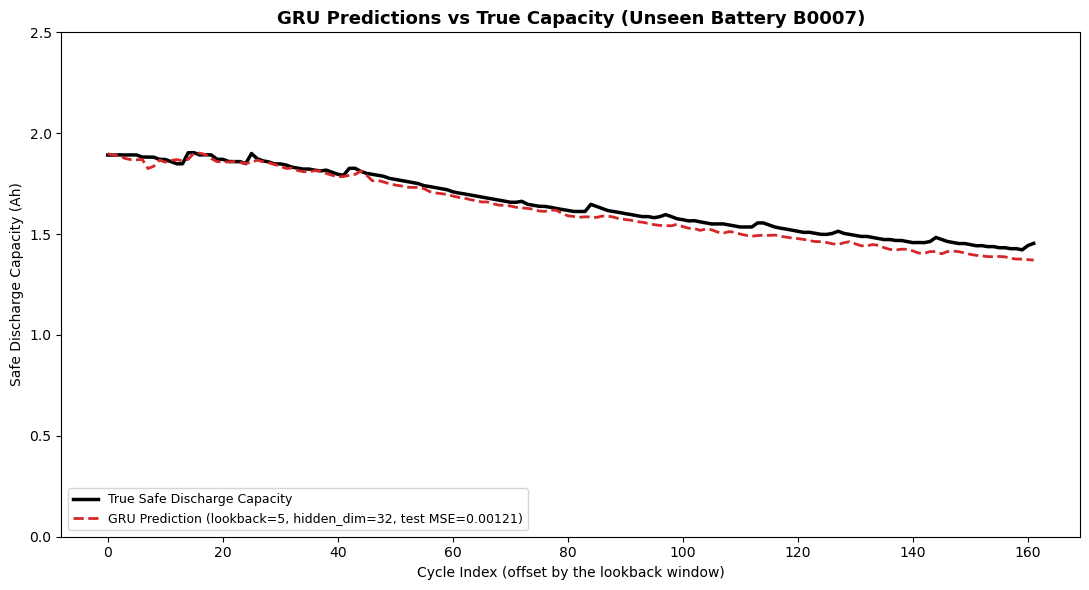

In [8]:
plt.figure(figsize=(11, 6), dpi=100)
plt.plot(actuals, label='True Safe Discharge Capacity', color='black', lw=2.5)
plt.plot(
    preds,
    label=f'GRU Prediction (lookback={LOOKBACK}, hidden_dim={HIDDEN_DIM}, test MSE={test_mse:.5f})',
    color='#d62728', linestyle='--', lw=2
)
plt.title('GRU Predictions vs True Capacity (Unseen Battery B0007)', fontsize=13, fontweight='bold')
plt.xlabel('Cycle Index (offset by the lookback window)')
plt.ylabel('Safe Discharge Capacity (Ah)')
plt.ylim(0, 2.5)
plt.legend(loc='lower left', fontsize=9, frameon=True)
plt.tight_layout()
plt.show()

## Things worth tuning

- **`LOOKBACK`** - how many past cycles the model gets to see. Too short and it can't learn a trend; too long and each battery yields fewer training sequences (a battery with `N` cycles gives `N - LOOKBACK` sequences).
- **`HIDDEN_DIM`** - the size of the memory vector. Larger can capture more complex patterns, but with ~300 training sequences it can also overfit quickly, same as the MLP depth experiment in `training_v4.ipynb`.
- **`NUM_LAYERS`** - stacking GRU layers (like the MLP's hidden layers). Same underfitting/overfitting tradeoffs as before likely apply, and more layers may need more `EPOCHS` to actually converge.
- **`EPOCHS` / `LR`** - recurrent nets can be slower to converge than a plain MLP since gradients have to flow through every timestep; if training MSE is still dropping steadily at epoch 100, it's worth training longer before concluding anything about the architecture.
